C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwar

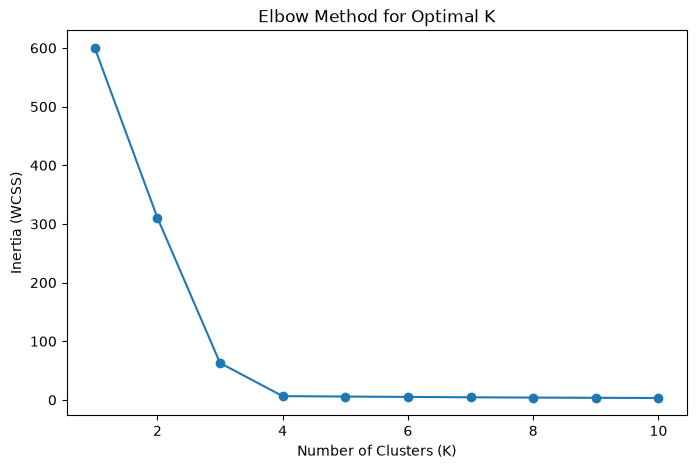

K=2, Silhouette Score=0.5822
K=3, Silhouette Score=0.7845
K=4, Silhouette Score=0.8796
K=5, Silhouette Score=0.7428
K=6, Silhouette Score=0.6039
K=7, Silhouette Score=0.4714
K=8, Silhouette Score=0.3371
K=9, Silhouette Score=0.3529
K=10, Silhouette Score=0.3669

Cluster labels (first 10): [3 3 0 1 3 1 2 1 0 2]
Centroids:
[[ 0.15256919  0.99257342]
 [-0.66142128 -1.56752677]
 [ 1.55047856 -0.13507979]
 [-1.04162647  0.71003314]]
Inertia: 6.42

New points assigned to clusters: [2 2]


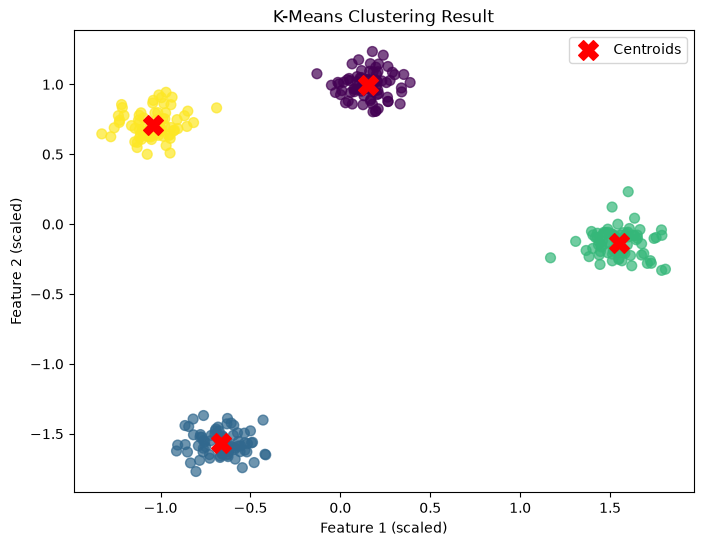

In [1]:
# ============================================
# K-Means Clustering - Complete Implementation
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# ---------------------------------------------
# 1. Create sample data (replace with your own dataset)
# ---------------------------------------------
X, y_true = make_blobs(
    n_samples=300,
    centers=4,  # actual number of clusters in the data
    cluster_std=0.60,
    random_state=42,
)

# ---------------------------------------------
# 2. Scale the data (IMPORTANT - K-Means is distance-based, just like KNN/SVM)
# ---------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------
# 3. Find the optimal K using the Elbow Method
# ---------------------------------------------
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(
        kmeans.inertia_
    )  # inertia = sum of squared distances to nearest centroid

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.show()

# ---------------------------------------------
# 4. Confirm optimal K using Silhouette Score (more reliable than elbow alone)
# ---------------------------------------------
silhouette_scores = []

for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

# ---------------------------------------------
# 5. Train final K-Means model with chosen K
# ---------------------------------------------
optimal_k = 4  # based on elbow/silhouette results above

kmeans_final = KMeans(
    n_clusters=optimal_k,
    init="k-means++",  # smart centroid initialization (better than random)
    n_init=10,  # runs algorithm 10 times with different seeds, picks best
    max_iter=300,  # max iterations per run
    random_state=42,
)

kmeans_final.fit(X_scaled)

# ---------------------------------------------
# 6. Get results
# ---------------------------------------------
labels = kmeans_final.labels_  # cluster assignment for each point
centroids = kmeans_final.cluster_centers_  # final centroid positions
inertia = kmeans_final.inertia_  # final WCSS value

print(f"\nCluster labels (first 10): {labels[:10]}")
print(f"Centroids:\n{centroids}")
print(f"Inertia: {inertia:.2f}")

# ---------------------------------------------
# 7. Predict cluster for NEW data points
# ---------------------------------------------
new_points = np.array([[0, 0], [4, 4]])
new_points_scaled = scaler.transform(new_points)
predicted_clusters = kmeans_final.predict(new_points_scaled)
print(f"\nNew points assigned to clusters: {predicted_clusters}")

# ---------------------------------------------
# 8. Visualize the clusters
# ---------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="viridis", s=50, alpha=0.7)
plt.scatter(
    centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, label="Centroids"
)
plt.title("K-Means Clustering Result")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.show()
